In [ ]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducible results
np.random.seed(42)

✅ Libraries imported successfully!
📚 OpenCV version: 4.12.0
📚 NumPy version: 2.2.4


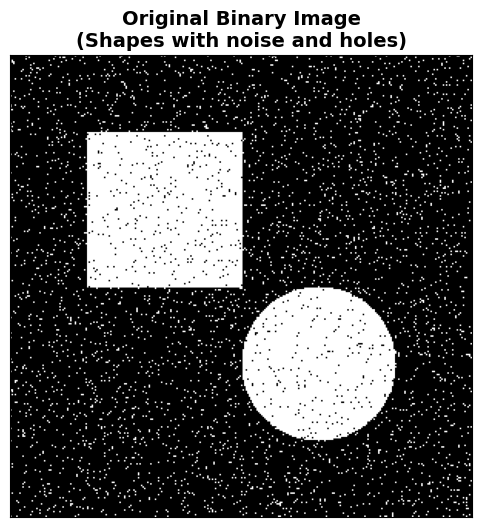

✅ Sample binary image created!
📏 Image shape: (300, 300)
🔢 Unique values: [  0 255]
📊 White pixels: 20974
📊 Black pixels: 69026


In [2]:
# Create a sample binary image for morphological operations
# This creates a simple shape with some noise to demonstrate the effects

# Create a black canvas
img = np.zeros((300, 300), dtype=np.uint8)

# Draw a white rectangle (main object)
cv2.rectangle(img, (50, 50), (150, 150), 255, -1)

# Draw a white circle (another object)
cv2.circle(img, (200, 200), 50, 255, -1)

# Add some noise (salt and pepper)
noise = np.random.random(img.shape) < 0.05  # 5% noise
img[noise] = 255

# Add some small holes (pepper noise)
holes = np.random.random(img.shape) < 0.03  # 3% holes
img[holes] = 0

# Display the original image
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Binary Image\n(Shapes with noise and holes)', fontsize=14, fontweight='bold')
plt.xticks([])
plt.yticks([])
plt.show()

print("✅ Sample binary image created!")
print(f"📏 Image shape: {img.shape}")
print(f"🔢 Unique values: {np.unique(img)}")
print(f"📊 White pixels: {np.sum(img == 255)}")
print(f"📊 Black pixels: {np.sum(img == 0)}")


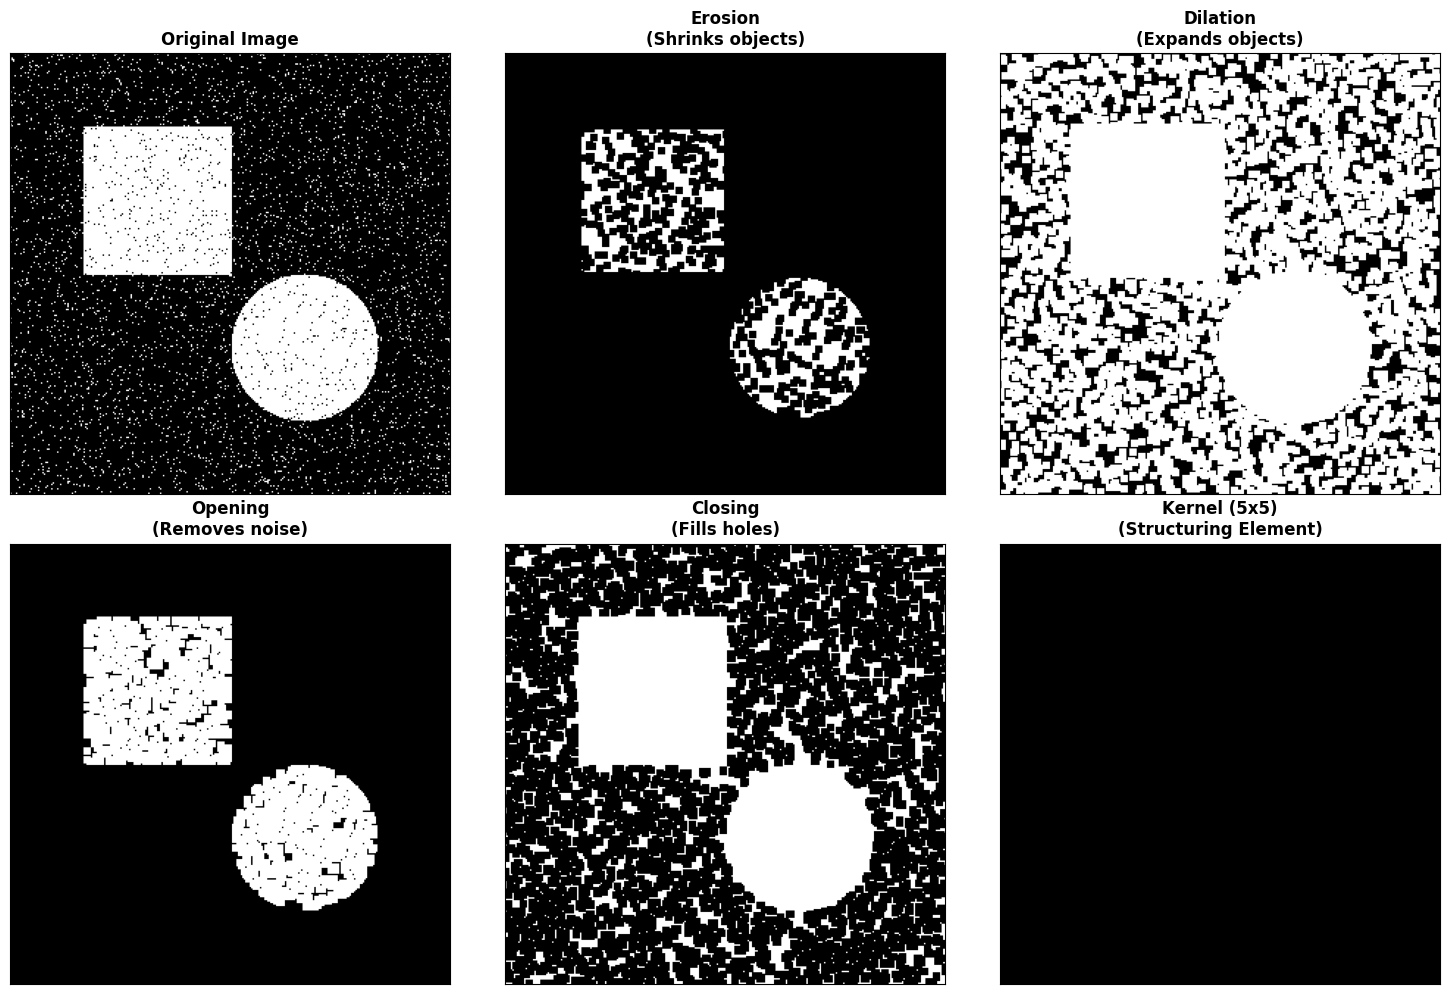

✅ Basic morphological operations completed!
🔧 Kernel size: (5, 5)
📊 Original white pixels: 20974
📊 After erosion: 7650
📊 After dilation: 68926
📊 After opening: 16420
📊 After closing: 31382


In [3]:
# Basic Morphological Operations
# Create a kernel (structuring element) for morphological operations
kernel = np.ones((5, 5), np.uint8)  # 5x5 square kernel

# 1. EROSION - Shrinks objects, removes small noise
erosion = cv2.erode(img, kernel, iterations=1)

# 2. DILATION - Expands objects, fills gaps
dilation = cv2.dilate(img, kernel, iterations=1)

# 3. OPENING - Erosion followed by dilation (removes noise)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# 4. CLOSING - Dilation followed by erosion (fills holes)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# Display all operations
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion\n(Shrinks objects)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation\n(Expands objects)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 4)
plt.imshow(opening, cmap='gray')
plt.title('Opening\n(Removes noise)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 5)
plt.imshow(closing, cmap='gray')
plt.title('Closing\n(Fills holes)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 6)
plt.imshow(kernel, cmap='gray')
plt.title('Kernel (5x5)\n(Structuring Element)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

print("✅ Basic morphological operations completed!")
print(f"🔧 Kernel size: {kernel.shape}")
print(f"📊 Original white pixels: {np.sum(img == 255)}")
print(f"📊 After erosion: {np.sum(erosion == 255)}")
print(f"📊 After dilation: {np.sum(dilation == 255)}")
print(f"📊 After opening: {np.sum(opening == 255)}")
print(f"📊 After closing: {np.sum(closing == 255)}")


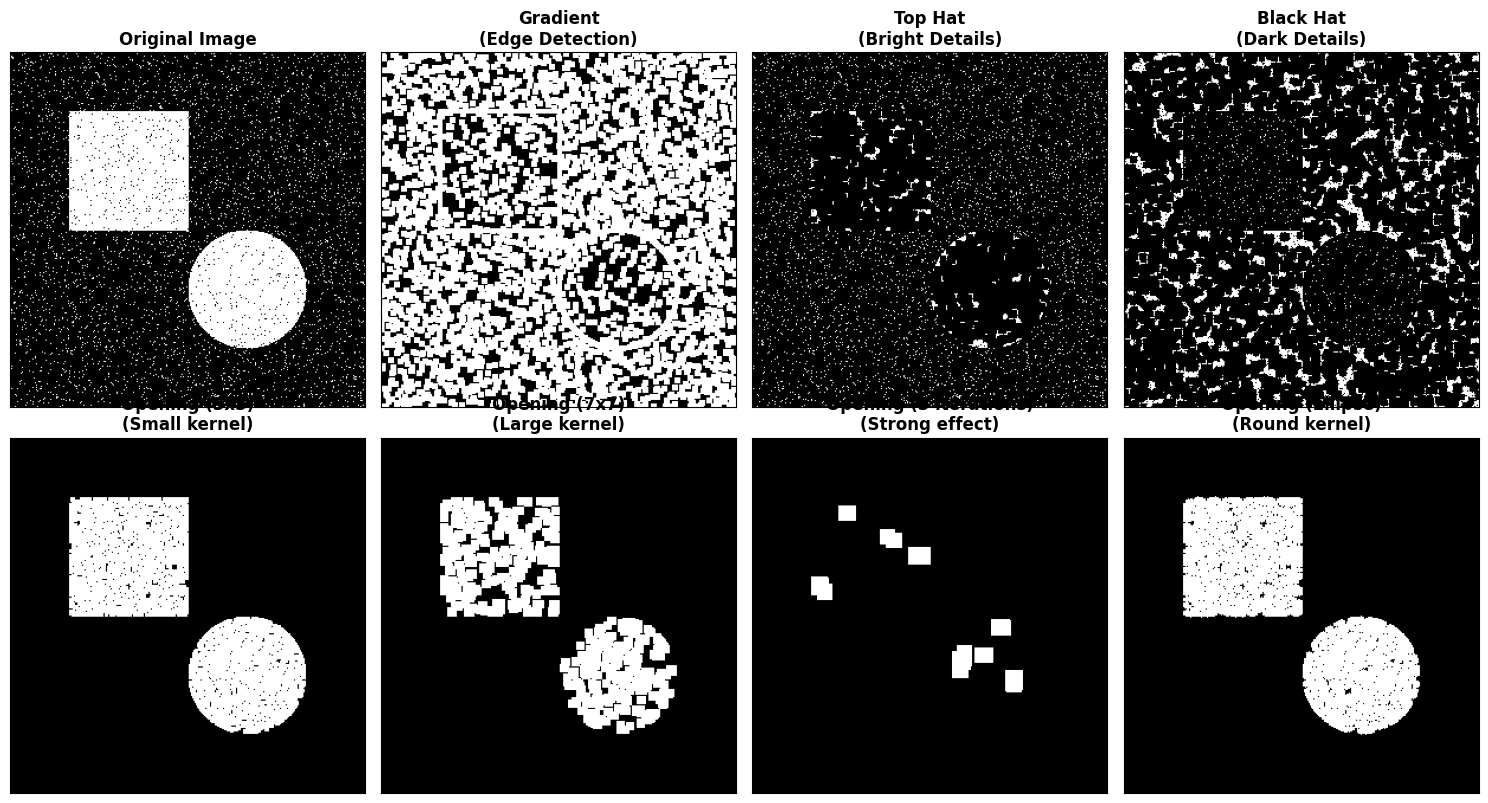

✅ Advanced morphological operations completed!
🔧 Small kernel (3x3): (3, 3)
🔧 Large kernel (7x7): (7, 7)
🔧 Ellipse kernel: (5, 5)
📊 Gradient pixels: 61276
📊 Top hat pixels: 4554
📊 Black hat pixels: 10408


In [4]:
# Advanced Morphological Operations
# These operations combine basic operations for specific effects

# 5. GRADIENT - Difference between dilation and erosion (edge detection)
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

# 6. TOP HAT - Difference between input and opening (bright details)
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

# 7. BLACK HAT - Difference between closing and input (dark details)
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

# 8. HIT OR MISS - Pattern matching (not available in OpenCV, but can be simulated)
# This is useful for finding specific patterns in binary images

# Display advanced operations
plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 4, 2)
plt.imshow(gradient, cmap='gray')
plt.title('Gradient\n(Edge Detection)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 4, 3)
plt.imshow(tophat, cmap='gray')
plt.title('Top Hat\n(Bright Details)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 4, 4)
plt.imshow(blackhat, cmap='gray')
plt.title('Black Hat\n(Dark Details)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

# Show the effect of different kernel sizes
plt.subplot(2, 4, 5)
kernel_small = np.ones((3, 3), np.uint8)
opening_small = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_small)
plt.imshow(opening_small, cmap='gray')
plt.title('Opening (3x3)\n(Small kernel)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 4, 6)
kernel_large = np.ones((7, 7), np.uint8)
opening_large = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_large)
plt.imshow(opening_large, cmap='gray')
plt.title('Opening (7x7)\n(Large kernel)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

# Show multiple iterations
plt.subplot(2, 4, 7)
opening_iter = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=3)
plt.imshow(opening_iter, cmap='gray')
plt.title('Opening (3 iterations)\n(Strong effect)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

# Show different kernel shapes
plt.subplot(2, 4, 8)
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opening_ellipse = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_ellipse)
plt.imshow(opening_ellipse, cmap='gray')
plt.title('Opening (Ellipse)\n(Round kernel)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

print("✅ Advanced morphological operations completed!")
print(f"🔧 Small kernel (3x3): {kernel_small.shape}")
print(f"🔧 Large kernel (7x7): {kernel_large.shape}")
print(f"🔧 Ellipse kernel: {kernel_ellipse.shape}")
print(f"📊 Gradient pixels: {np.sum(gradient == 255)}")
print(f"📊 Top hat pixels: {np.sum(tophat == 255)}")
print(f"📊 Black hat pixels: {np.sum(blackhat == 255)}")


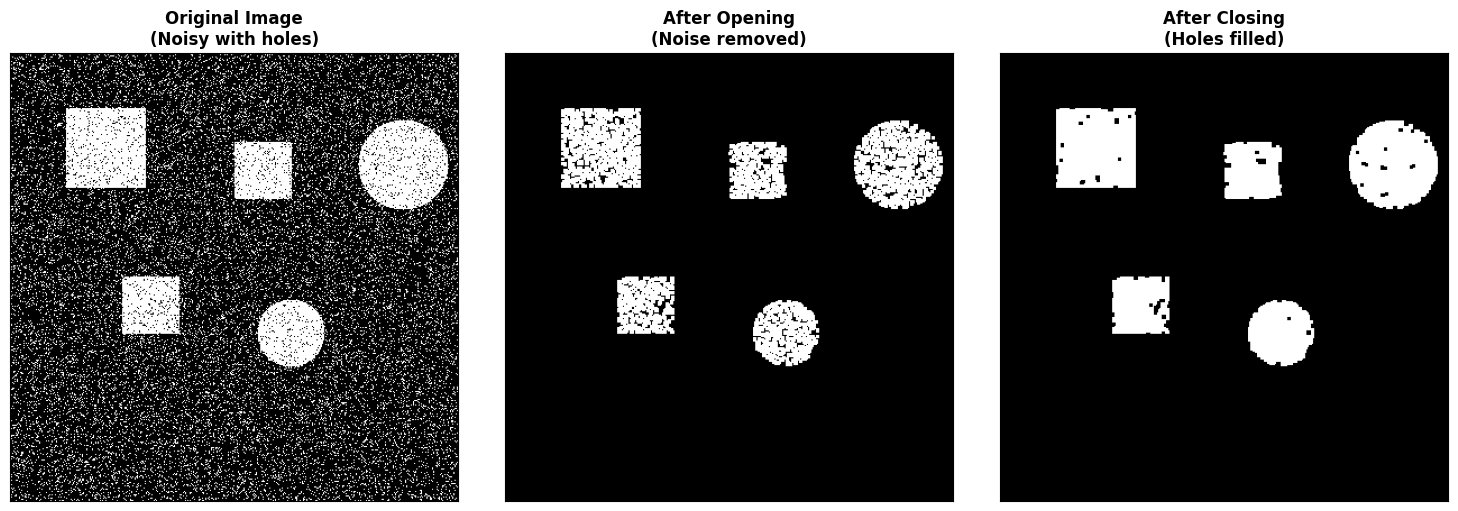

✅ Practical example completed!
📊 Original white pixels: 36051
📊 Final white pixels: 17029
🎯 Noise reduction: 52.8%
🔧 Kernel used: (3, 3)


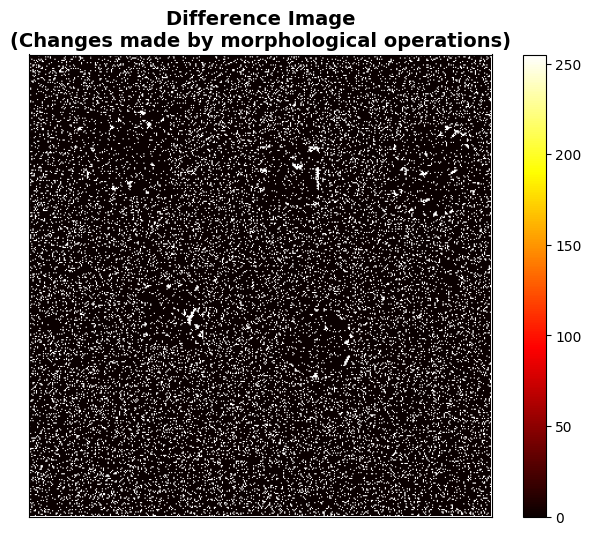

In [5]:
# Practical Example: Noise Reduction and Object Enhancement
# This demonstrates how morphological operations can be used in real-world scenarios

# Create a more complex binary image with various objects and noise
complex_img = np.zeros((400, 400), dtype=np.uint8)

# Draw multiple objects of different sizes
cv2.rectangle(complex_img, (50, 50), (120, 120), 255, -1)      # Large rectangle
cv2.rectangle(complex_img, (200, 80), (250, 130), 255, -1)     # Medium rectangle
cv2.circle(complex_img, (350, 100), 40, 255, -1)               # Circle
cv2.rectangle(complex_img, (100, 200), (150, 250), 255, -1)    # Small rectangle
cv2.circle(complex_img, (250, 250), 30, 255, -1)               # Small circle

# Add significant noise
noise = np.random.random(complex_img.shape) < 0.15  # 15% noise
complex_img[noise] = 255

# Add holes in objects
holes = np.random.random(complex_img.shape) < 0.08  # 8% holes
complex_img[holes] = 0

# Apply morphological operations for cleaning
kernel_clean = np.ones((3, 3), np.uint8)

# Step 1: Opening to remove noise
cleaned = cv2.morphologyEx(complex_img, cv2.MORPH_OPEN, kernel_clean)

# Step 2: Closing to fill holes
final_result = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_clean)

# Display the cleaning process
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(complex_img, cmap='gray')
plt.title('Original Image\n(Noisy with holes)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(cleaned, cmap='gray')
plt.title('After Opening\n(Noise removed)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(final_result, cmap='gray')
plt.title('After Closing\n(Holes filled)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

# Calculate improvement metrics
original_white = np.sum(complex_img == 255)
final_white = np.sum(final_result == 255)
noise_reduction = ((original_white - final_white) / original_white) * 100

print("✅ Practical example completed!")
print(f"📊 Original white pixels: {original_white}")
print(f"📊 Final white pixels: {final_white}")
print(f"🎯 Noise reduction: {noise_reduction:.1f}%")
print(f"🔧 Kernel used: {kernel_clean.shape}")

# Show the difference
difference = cv2.absdiff(complex_img, final_result)
plt.figure(figsize=(8, 6))
plt.imshow(difference, cmap='hot')
plt.title('Difference Image\n(Changes made by morphological operations)', fontsize=14, fontweight='bold')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()


Morphological Operators are sets of kernels that can achive a variety of effetcs such as reducing noise.
certain operators are very good at reducing black points on a white background (and vice versa)

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

In [7]:
def load_img():
    blank_img = np.zeros((600, 600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img, text='ABCDE', org=(50, 300), fontFace=font, fontScale=5, color=(255, 255, 255), thickness=25)
    return blank_img

In [8]:
def display_img(img):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

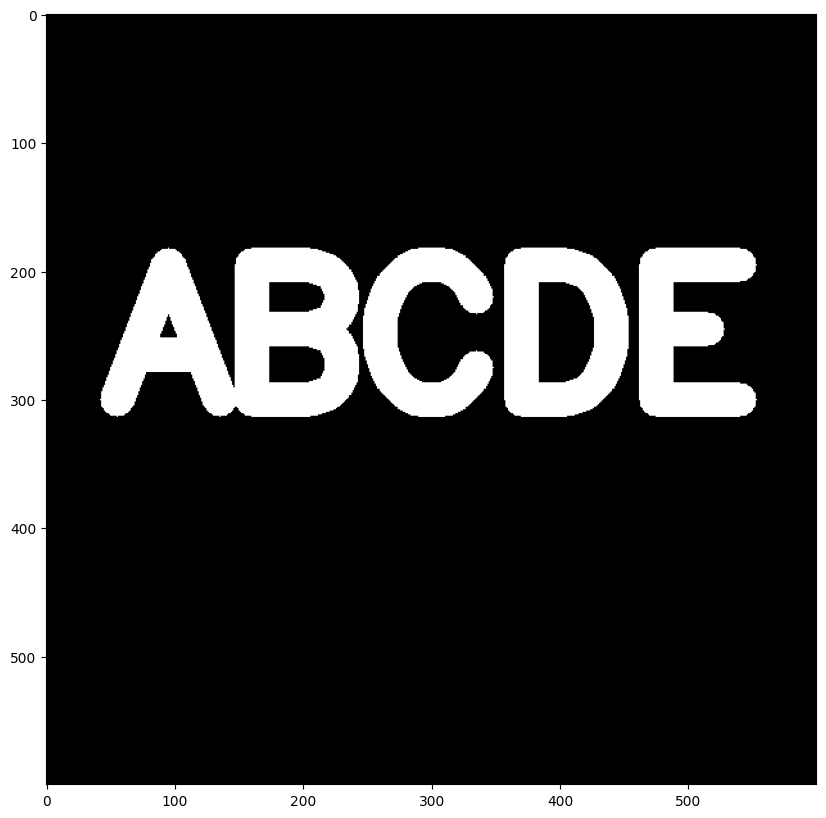

In [9]:
img = load_img()
display_img(img)

In [10]:
kernel = np.ones((5, 5), dtype=np.uint8)

In [11]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [12]:
result = cv2.erode(img, kernel, iterations=4)

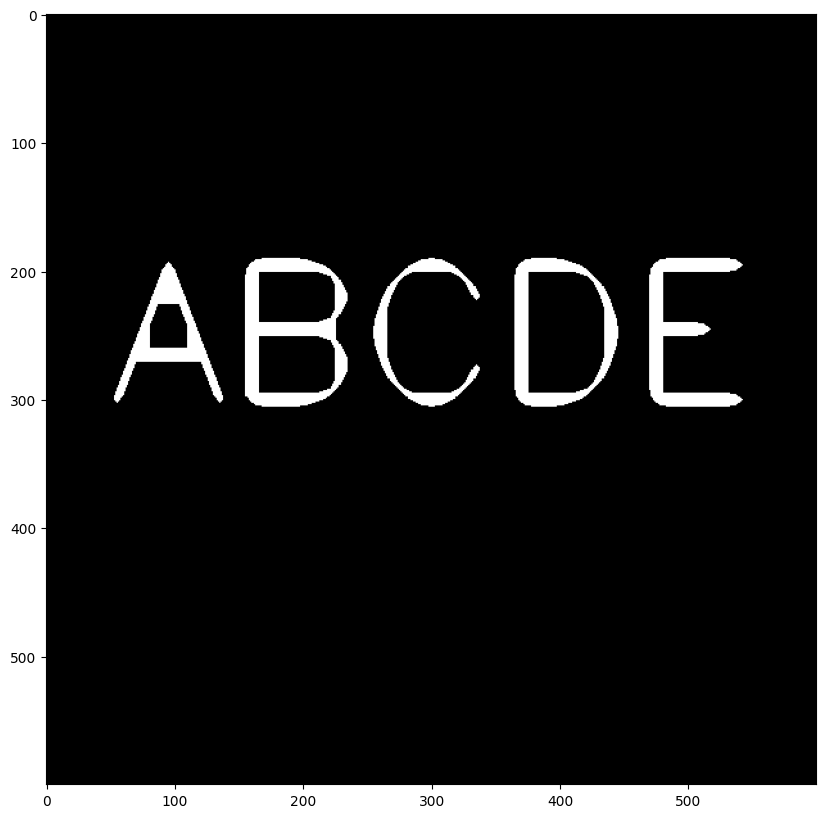

In [13]:
display_img(result)

In [14]:
# Opening : helpful in removing background noise 

In [15]:
img = load_img()

In [16]:
white_noise = np.random.randint(low=0, high=2, size=(600, 600))

In [17]:
white_noise

array([[0, 0, 1, ..., 1, 0, 1],
       [1, 1, 1, ..., 0, 0, 1],
       [0, 0, 1, ..., 1, 0, 0],
       ...,
       [1, 0, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 1, 1, ..., 0, 0, 1]], shape=(600, 600), dtype=int32)

In [18]:
# display_img(white_noise)

In [19]:
img.max()

np.float64(255.0)

In [20]:
white_noise = white_noise * 255 

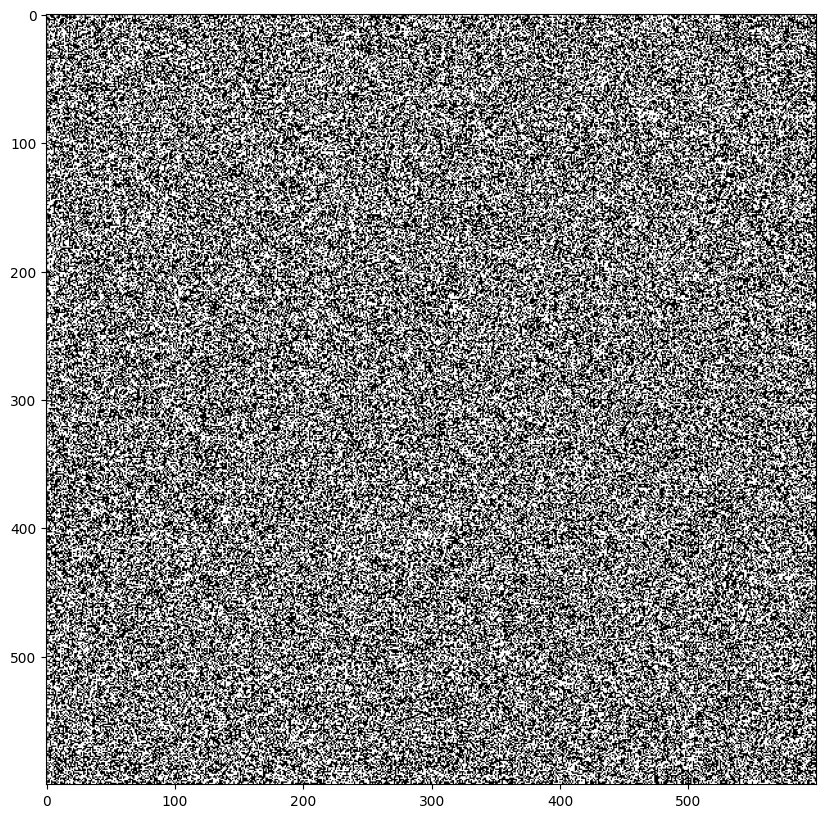

In [21]:
display_img(white_noise)

In [22]:
noise_img = white_noise + img

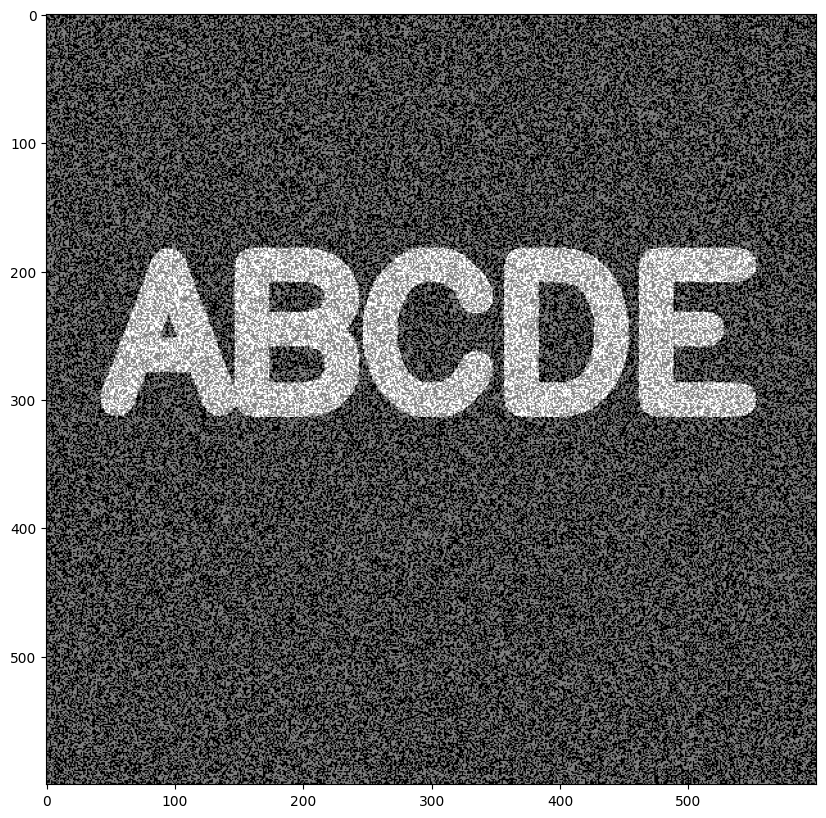

In [23]:
display_img(noise_img)

In [24]:
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

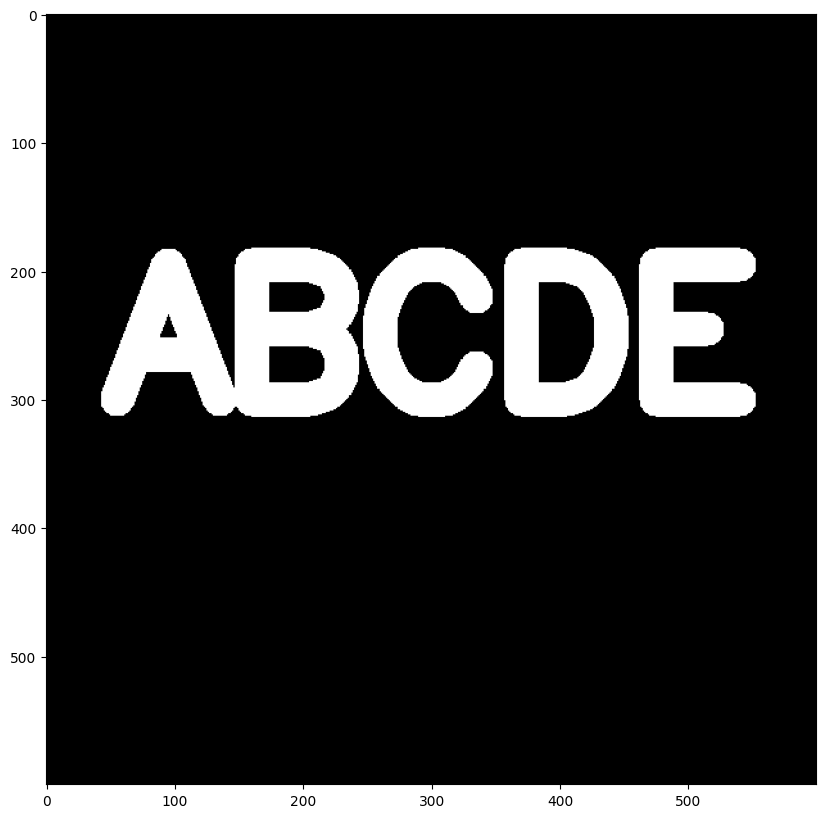

In [25]:
display_img(opening)

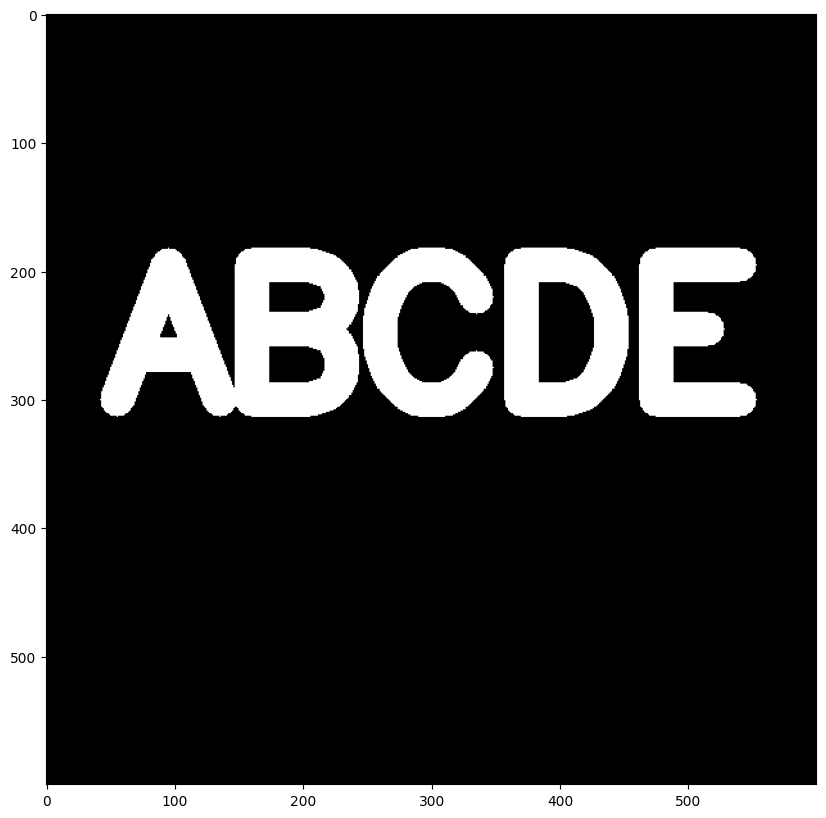

In [26]:
display_img(img)

In [27]:
img = load_img()

In [28]:
black_noise = np.random.randint(low=0, high=2, size=(600, 600))

In [29]:
black_noise = black_noise * -255 

In [30]:
black_noise

array([[-255, -255, -255, ..., -255,    0, -255],
       [-255, -255,    0, ...,    0, -255,    0],
       [   0,    0, -255, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ..., -255, -255,    0],
       [-255, -255,    0, ..., -255,    0, -255],
       [-255, -255,    0, ..., -255, -255, -255]],
      shape=(600, 600), dtype=int32)

In [31]:
black_noise_img = img + black_noise 

In [32]:
black_noise_img 

array([[-255., -255., -255., ..., -255.,    0., -255.],
       [-255., -255.,    0., ...,    0., -255.,    0.],
       [   0.,    0., -255., ...,    0.,    0.,    0.],
       ...,
       [   0.,    0.,    0., ..., -255., -255.,    0.],
       [-255., -255.,    0., ..., -255.,    0., -255.],
       [-255., -255.,    0., ..., -255., -255., -255.]], shape=(600, 600))

In [33]:
black_noise_img[black_noise_img == -255] = 0

In [34]:
black_noise_img.min()

np.float64(0.0)

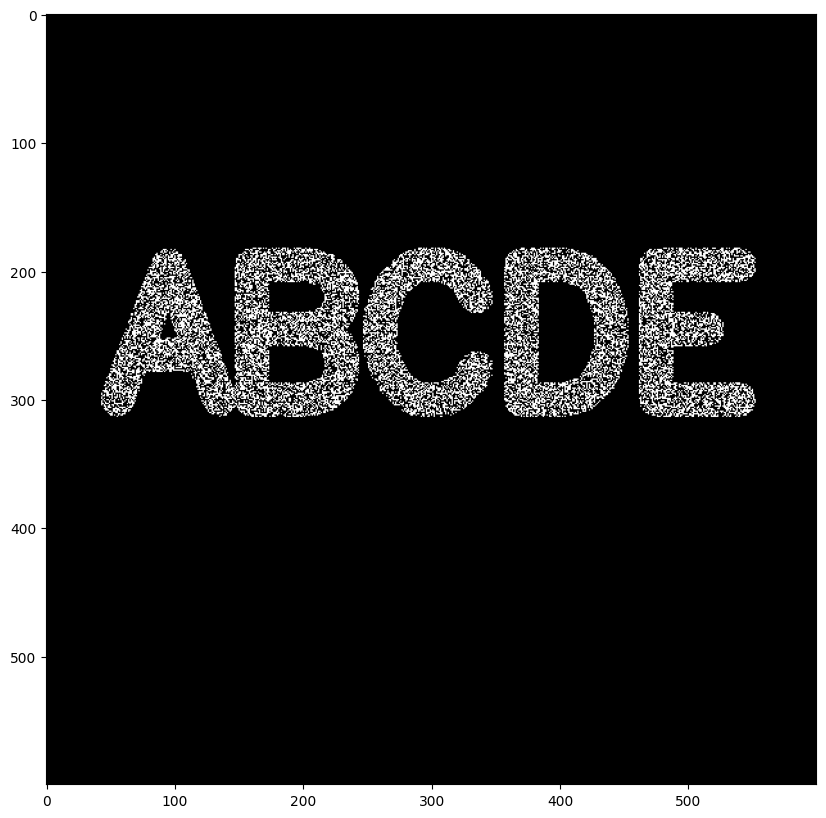

In [35]:
display_img(black_noise_img)

In [36]:
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)

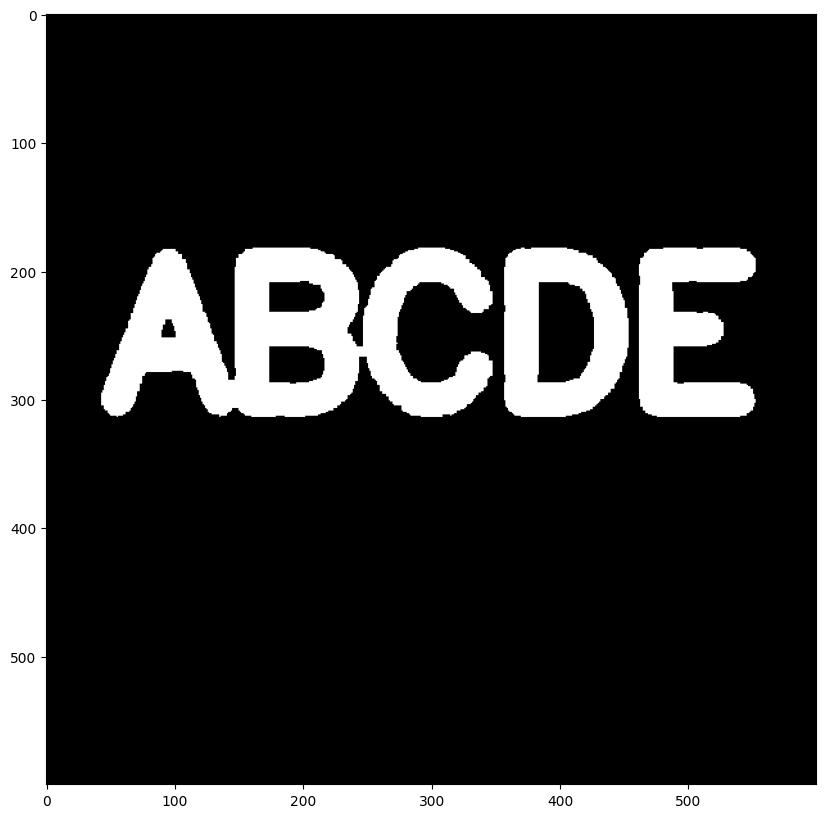

In [37]:
display_img(closing)

Edge Detection 

In [38]:
img = load_img()

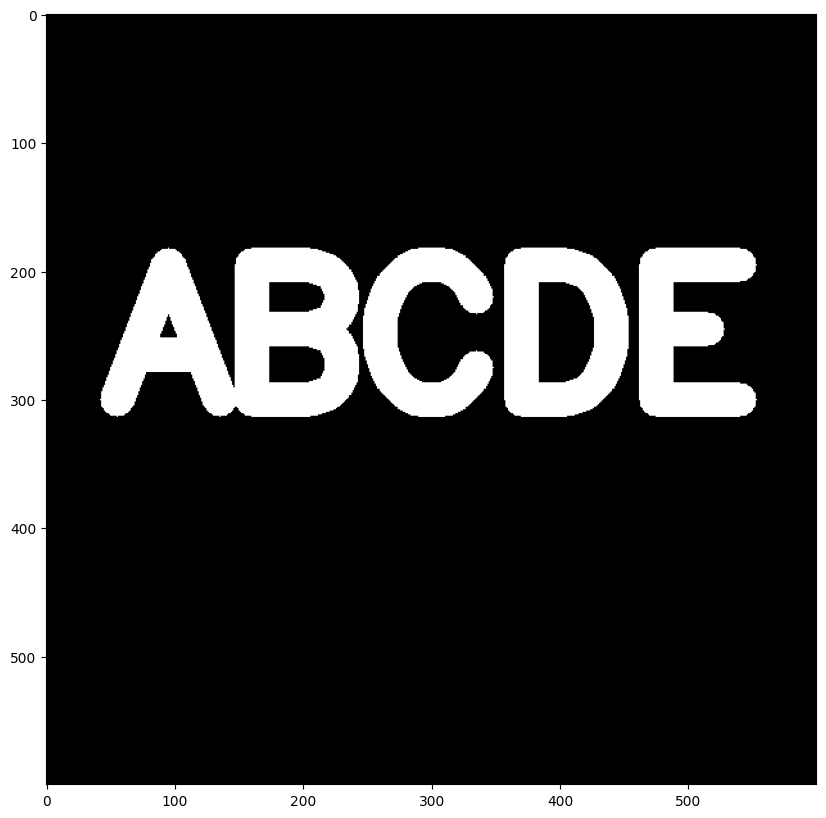

In [39]:
display_img(img)

In [40]:
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

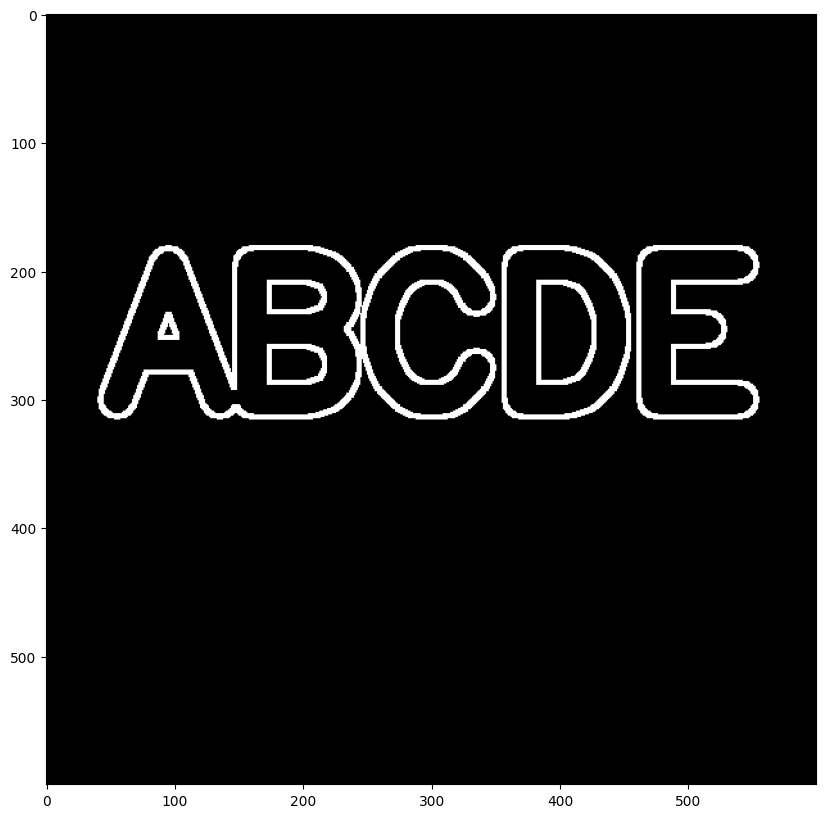

In [41]:
display_img(gradient)